# MNIST MLP Classifier

This notebook trains a basic multilayer perceptron on MNIST with MoTorch and
NumPy. The model is intentionally simple: the goal is to show the full data
loading, batching, training, and evaluation workflow rather than push for a
state-of-the-art score.

In [1]:
import gzip
import pathlib
import struct
import urllib.request

import matplotlib.pyplot as plt
import numpy as np

import motorch as mo
import motorch.nn as nn
import motorch.optim as optim
from motorch.data import DataLoader, TensorDataset

## Download MNIST

MNIST IDX gzip files are downloaded with `urllib.request` and cached under
`examples/data/mnist/`.

In [2]:
MNIST_BASE_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

project_root = pathlib.Path.cwd()
if project_root.name == "examples":
    data_dir = project_root / "data" / "mnist"
else:
    data_dir = project_root / "examples" / "data" / "mnist"

data_dir.mkdir(parents=True, exist_ok=True)
data_dir

PosixPath('/home/jcorrieri/projects/motorch/examples/data/mnist')

In [3]:
def download_mnist_file(filename):
    destination = data_dir / filename
    if destination.exists():
        return destination

    url = MNIST_BASE_URL + filename
    print(f"Downloading {url} -> {destination}")
    urllib.request.urlretrieve(url, destination)
    return destination


mnist_paths = {
    name: download_mnist_file(filename)
    for name, filename in MNIST_FILES.items()
}
mnist_paths

{'train_images': PosixPath('/home/jcorrieri/projects/motorch/examples/data/mnist/train-images-idx3-ubyte.gz'),
 'train_labels': PosixPath('/home/jcorrieri/projects/motorch/examples/data/mnist/train-labels-idx1-ubyte.gz'),
 'test_images': PosixPath('/home/jcorrieri/projects/motorch/examples/data/mnist/t10k-images-idx3-ubyte.gz'),
 'test_labels': PosixPath('/home/jcorrieri/projects/motorch/examples/data/mnist/t10k-labels-idx1-ubyte.gz')}

## Parse IDX Files

Images are normalized to `float32` values in `[0, 1]` and flattened to 784
features. The loss expects one-hot labels, while integer labels are kept for
accuracy reporting.

In [4]:
def read_idx_images(path):
    with gzip.open(path, "rb") as file:
        magic, count, rows, columns = struct.unpack(">IIII", file.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number: {magic}")

        data = np.frombuffer(file.read(), dtype=np.uint8)

    images = data.reshape(count, rows * columns)
    return images.astype(np.float32) / 255.0


def read_idx_labels(path):
    with gzip.open(path, "rb") as file:
        magic, count = struct.unpack(">II", file.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number: {magic}")

        labels = np.frombuffer(file.read(), dtype=np.uint8)

    return labels.astype(np.int64)


all_train_images = read_idx_images(mnist_paths["train_images"])
all_train_labels = read_idx_labels(mnist_paths["train_labels"])
test_images = read_idx_images(mnist_paths["test_images"])
test_labels = read_idx_labels(mnist_paths["test_labels"])

validation_size = 10_000
train_images = all_train_images[:-validation_size]
train_labels = all_train_labels[:-validation_size]
validation_images = all_train_images[-validation_size:]
validation_labels = all_train_labels[-validation_size:]

def one_hot(labels, classes=10):
    encoded = np.zeros((len(labels), classes), dtype=np.float32)
    encoded[np.arange(len(labels)), labels] = 1.0
    return encoded


train_targets = one_hot(train_labels)
validation_targets = one_hot(validation_labels)
test_targets = one_hot(test_labels)

train_images.shape, validation_images.shape, test_images.shape

((50000, 784), (10000, 784), (10000, 784))

## Build Datasets and Loaders

Each dataset stores features, one-hot targets for `CrossEntropyLoss`, and
integer labels for accuracy metrics.

In [5]:
batch_size = 256
loader_rng = np.random.default_rng(seed=42)

train_dataset = TensorDataset(
    mo.tensor(train_images),
    mo.tensor(train_targets),
    mo.tensor(train_labels),
)
validation_dataset = TensorDataset(
    mo.tensor(validation_images),
    mo.tensor(validation_targets),
    mo.tensor(validation_labels),
)
test_dataset = TensorDataset(
    mo.tensor(test_images),
    mo.tensor(test_targets),
    mo.tensor(test_labels),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    rng=loader_rng,
)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

train_loader, validation_loader, test_loader

(<motorch.data.dataloader.DataLoader at 0x7c02c5faec30>,
 <motorch.data.dataloader.DataLoader at 0x7c02c5fae210>)

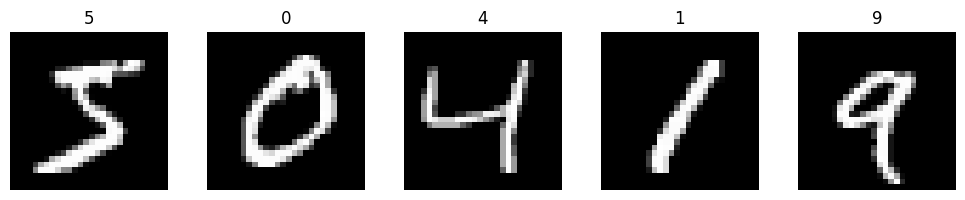

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for axis, image, label in zip(axes, train_images[:5], train_labels[:5]):
    axis.imshow(image.reshape(28, 28), cmap="gray")
    axis.set_title(str(label))
    axis.axis("off")

plt.tight_layout()

## Define an MLP

The model emits 10 logits, one per MNIST class.

In [7]:
class MNISTMLP(nn.Module):
    def __init__(self, input_features=784, hidden_features=128, classes=10):
        super().__init__()
        self.layer_1 = nn.Linear(input_features, hidden_features)
        self.activation_1 = nn.ReLU()
        self.layer_2 = nn.Linear(hidden_features, hidden_features)
        self.activation_2 = nn.ReLU()
        self.output = nn.Linear(hidden_features, classes)

    def forward(self, x):
        x = self.activation_1(self.layer_1(x))
        x = self.activation_2(self.layer_2(x))
        return self.output(x)


rng = np.random.default_rng(seed=7)
model = MNISTMLP()

for layer in [model.layer_1, model.layer_2, model.output]:
    nn.init.glorot(rng, layer.weight, gain=np.sqrt(2.0))
    nn.init.zeros(layer.bias)

model

MNISTMLP(
  (layer_1): Linear(in_features=784, out_features=128, bias=True)
  (activation_1): ReLU()
  (layer_2): Linear(in_features=128, out_features=128, bias=True)
  (activation_2): ReLU()
  (output): Linear(in_features=128, out_features=10, bias=True)
)

## Train

MoTorch's cross-entropy currently expects one-hot labels, so the loader yields
both one-hot targets and integer labels.

In [8]:
def accuracy(logits, integer_labels):
    predictions = np.argmax(logits.data, axis=1)
    return np.mean(predictions == integer_labels.data)


def evaluate(model, loader, criterion):
    losses = []
    accuracies = []

    with mo.no_grad():
        for images, targets, integer_labels in loader:
            logits = model(images)
            losses.append(float(criterion(logits, targets).item()))
            accuracies.append(accuracy(logits, integer_labels))

    return np.mean(losses), np.mean(accuracies)


criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
num_epochs = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
}

for epoch in range(num_epochs):
    batch_losses = []
    batch_accuracies = []

    for images, targets, integer_labels in train_loader:
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_losses.append(float(loss.item()))
        batch_accuracies.append(accuracy(logits, integer_labels))

    validation_loss, validation_accuracy = evaluate(model, validation_loader, criterion)
    train_loss = np.mean(batch_losses)
    train_accuracy = np.mean(batch_accuracies)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train loss {train_loss:.3f}, train acc {train_accuracy:.3f} | "
        f"val loss {validation_loss:.3f}, val acc {validation_accuracy:.3f}"
    )

Epoch 1/5 | train loss 0.530, train acc 0.847 | val loss 0.309, val acc 0.908
Epoch 2/5 | train loss 0.260, train acc 0.923 | val loss 0.222, val acc 0.933
Epoch 3/5 | train loss 0.210, train acc 0.938 | val loss 0.211, val acc 0.938
Epoch 4/5 | train loss 0.180, train acc 0.947 | val loss 0.163, val acc 0.954
Epoch 5/5 | train loss 0.157, train acc 0.954 | val loss 0.142, val acc 0.961


## Evaluate

A basic MLP should learn the digit structure well enough for a useful demo, but
it will not match convolutional MNIST models.

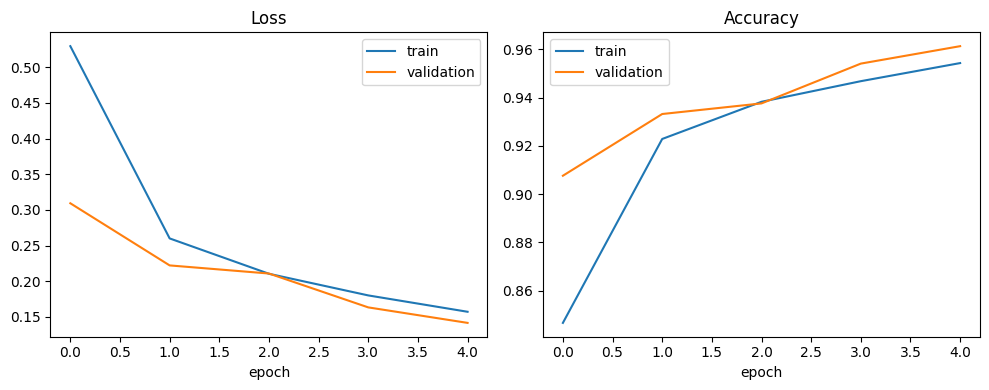

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["validation_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_accuracy"], label="train")
axes[1].plot(history["validation_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()

In [10]:
test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f"Test loss: {test_loss:.3f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Test loss: 0.151
Test accuracy: 95.46%


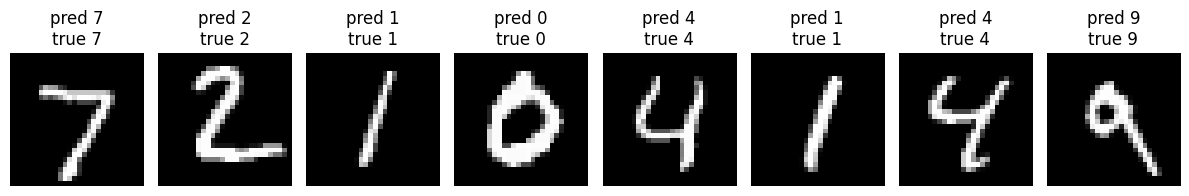

In [11]:
sample_images, _, sample_labels = next(iter(test_loader))

with mo.no_grad():
    sample_logits = model(sample_images)

sample_predictions = np.argmax(sample_logits.data, axis=1)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for axis, image, prediction, label in zip(
    axes,
    sample_images.data[:8],
    sample_predictions[:8],
    sample_labels.data[:8],
):
    axis.imshow(image.reshape(28, 28), cmap="gray")
    axis.set_title(f"pred {prediction}\ntrue {label}")
    axis.axis("off")

plt.tight_layout()